In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.cluster import DBSCAN, HDBSCAN
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
import os
from sklearn.preprocessing import MinMaxScaler
import glob
import matplotlib.colors as mcolors
from sklearn.metrics import silhouette_samples
from astropy.coordinates import SkyCoord
import astropy.units as u
import plotly.graph_objects as go


In [2]:
def silhouette_por_cluster_dataframe(df, cluster_col='cluster', feature_cols=None):
    # Excluir ruido
    df_valido = df[df[cluster_col] != -1].copy()

    if feature_cols is None:
        # Detectar columnas numéricas automáticamente si no se especifican
        feature_cols = df_valido.select_dtypes(include=['float64', 'int64']).columns.tolist()
        feature_cols.remove(cluster_col)

    X = df_valido[feature_cols].values
    labels = df_valido[cluster_col].values

    # Calcular silhouette por muestra
    sil_values = silhouette_samples(X, labels)

    df_valido['silhouette'] = sil_values

    # Agrupar por clúster y calcular promedio
    silhouette_mean = df_valido.groupby(cluster_col)['silhouette'].mean()

    return silhouette_mean

In [3]:
df = pd.read_csv("datos_resultados_modularizado/hdbscan_ra180_dec-30_prev.csv")
df = df.sort_values(by=['source_id','ConteoAgrupaciones'], ascending=[False,False]).drop_duplicates(subset=['source_id'], keep='first')
df['probabilidad'] = df['ConteoAgrupaciones']/(df['iteraciones']*10)
df = df[df['probabilidad']>0.7]

In [4]:
df['parallax_over_error'] = abs(df['parallax']/df['parallax_error'])
df['parallax_relative_error'] = 1/df['parallax_over_error']*100
df['pmra_over_error'] = abs(df['pmra']/df['pmra_error'])
df['pmra_relative_error'] = 1/df['pmra_over_error']*100
df['pmdec_over_error'] = abs(df['pmdec']/df['pmdec_error'])
df['pmdec_relative_error'] = 1/df['pmdec_over_error']*100
df['ra_over_error'] = abs(df['ra']/df['ra_error'])
df['ra_relative_error'] = 1/df['ra_over_error']*100
df['dec_over_error'] = abs(df['dec']/df['dec_error'])
df['dec_relative_error'] = 1/df['dec_over_error']*100
# Convertir paralaje a distancia en parsecs
df['distance_pc'] = 1000 / df['parallax']  # pc

# Crear objetos SkyCoord vectorizados
coords = SkyCoord(ra=df['ra'].values * u.degree,
                  dec=df['dec'].values * u.degree,
                  distance=df['distance_pc'].values * u.pc,
                  frame='icrs')

# Extraer coordenadas cartesianas
df['x_pc'] = coords.cartesian.x.value
df['y_pc'] = coords.cartesian.y.value
df['z_pc'] = coords.cartesian.z.value
# len(df[df['relative_error']>df['relative_error'].quantile(0.75) +((df['relative_error'].quantile(0.75)-df['relative_error'].quantile(0.25))/2)])

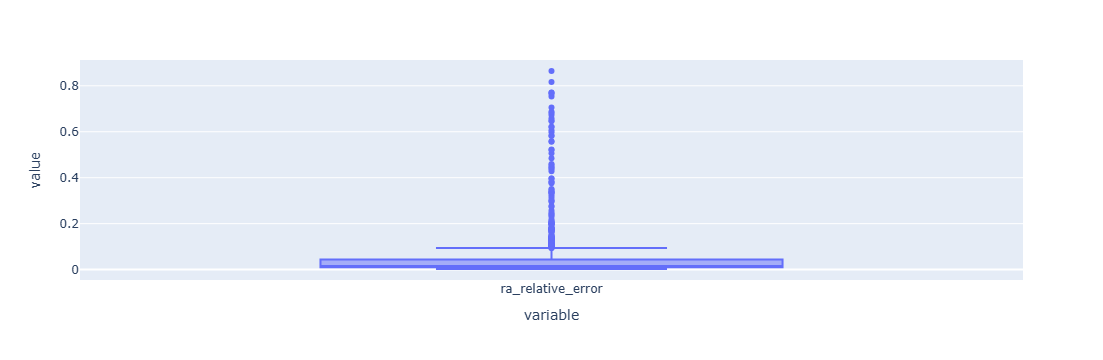

In [5]:
px.box(df['ra_relative_error'])

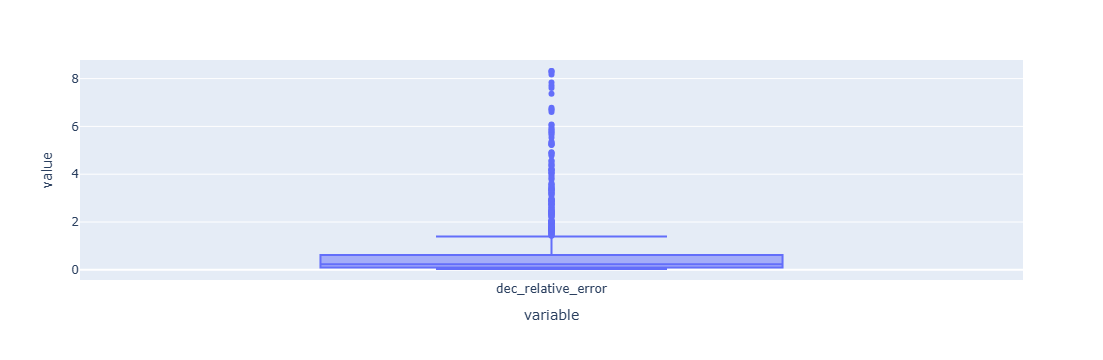

In [6]:
px.box(df['dec_relative_error'])

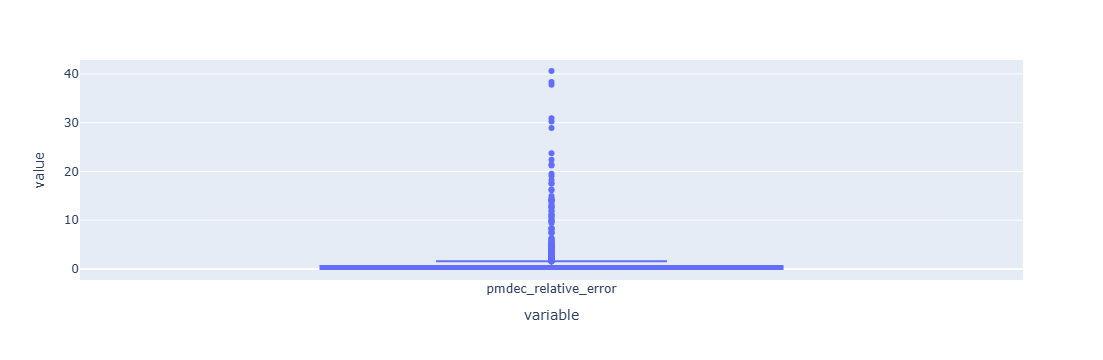

In [7]:
px.box(df['pmdec_relative_error'])

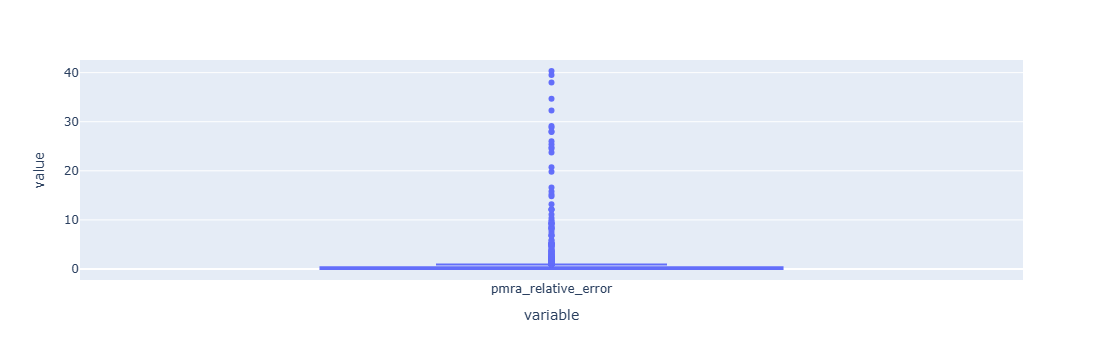

In [8]:
px.box(df['pmra_relative_error'])

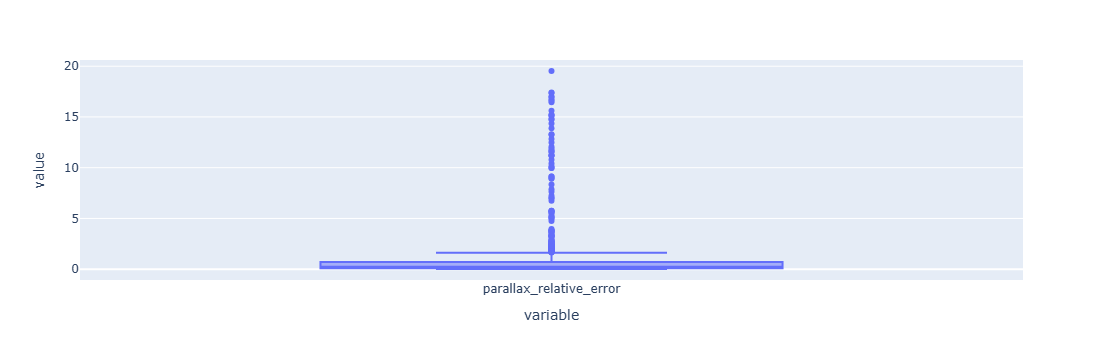

In [9]:
px.box(df['parallax_relative_error'])

(array([963.,  60.,  22.,  11.,   8.,   7.,   7.,   9.,   5.,   2.]),
 array([0.00267395, 0.088852  , 0.17503005, 0.2612081 , 0.34738615,
        0.4335642 , 0.51974225, 0.6059203 , 0.69209834, 0.77827639,
        0.86445444]),
 <BarContainer object of 10 artists>)

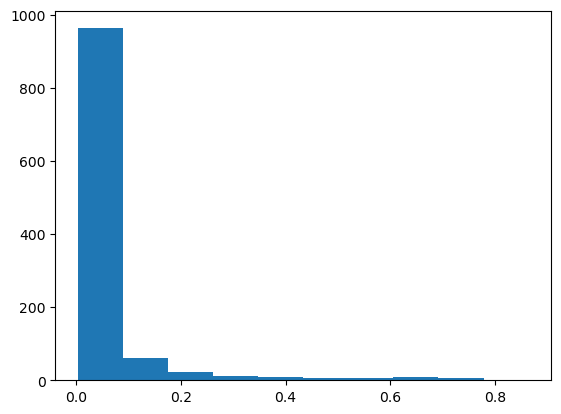

In [10]:
plt.hist(df['ra_relative_error'])

(array([558.,  14.,  24.,  51., 115.,  70.,  39.,  33.,  24.,  22.,  25.,
         10.,   9.,  10.,  11.,   3.,   2.,   6.,   6.,   2.,   0.,   2.,
          1.,   1.,   3.,   2.,   0.,   1.,   0.,   1.,   0.,   1.,   1.,
          1.,   0.,   0.,   1.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   1.,   1.]),
 array([ 10.0005232 ,  14.42288269,  18.84524218,  23.26760167,
         27.68996117,  32.11232066,  36.53468015,  40.95703964,
         45.37939913,  49.80175863,  54.22411812,  58.64647761,
         63.0688371 ,  67.49119659,  71.91355609,  76.33591558,
         80.75827507,  85.18063456,  89.60299405,  94.02535355,
         98.44771304, 102.87007253, 107.29243202, 111.71479152,
        116.13715101, 120.5595105 , 124.98186999, 129.40422948,
        133.82658898, 138.24894847, 142.67130796, 147.09366745,
        151.51602694, 155.93838644, 160.36074593, 164.78310542,
        169.20546491, 173.62782441, 178.0501839 , 182.47254339,
        186.894902

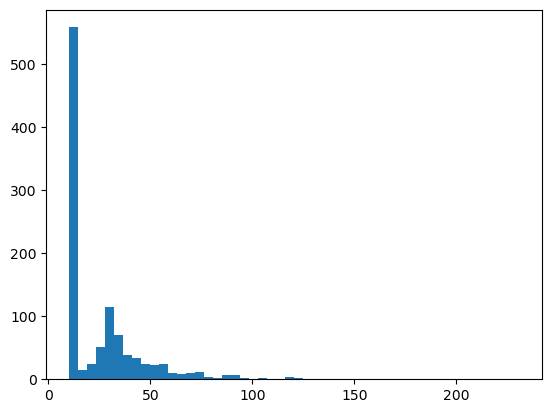

In [11]:
plt.hist(df[df['parallax_relative_error']<=7]['parallax'], bins=50)

(0.0, 7.0)

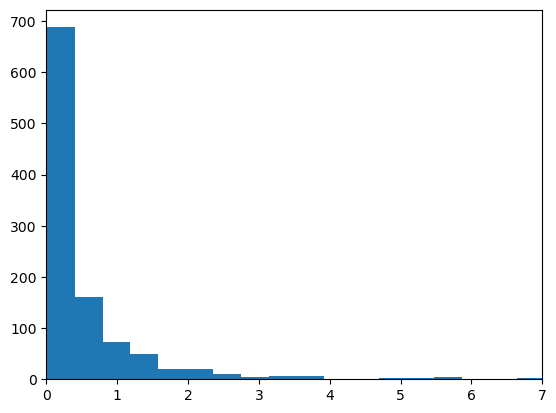

In [12]:
plt.hist(df['parallax_relative_error'], bins=50)
plt.xlim(0,7)

In [13]:
# df['probabilidad'] = MinMaxScaler().fit_transform(df['ConteoAgrupaciones'].values.reshape(-1, 1))
# df = df[df['probabilidad']>0.5]

In [14]:
# definicion de parametros y modelo a ejecutar
min_pts = 20
max_pts = 1500

hdbscan = HDBSCAN(min_cluster_size=min_pts, max_cluster_size=max_pts)
#hdbscan.fit(df[['pmra_norm', 'pmdec_norm', 'parallax_norm','ra_norm','dec_norm']])
hdbscan.fit(df[['pmra_norm', 'pmdec_norm', 'parallax_norm','ra_norm','dec_norm']])
etiquetas = hdbscan.labels_
df['cluster'] = etiquetas
np.unique(etiquetas, return_counts=True)

# Paso 1: Calcular el tamaño de cada cluster
top_clusters = df['cluster'].value_counts().nlargest(50).index

# Paso 2: Filtrar el DataFrame con esos clusters
dff = df[df['cluster'].isin(top_clusters)].copy()

# listado de clusters generados
clusters = np.sort(dff['cluster'].unique())
# Crear un colormap con tantos colores como clusters
colormap = cm.get_cmap('Set1', len(top_clusters))  # o 'tab20', 'nipy_spectral', etc.

# Crear un diccionario de colores para cada cluster
color_dict = {cluster: colormap(i) for i, cluster in enumerate(top_clusters)}

# Asignar el color correspondiente a cada fila
dff['color'] = dff['cluster'].map(color_dict)

C:\Users\nicob\AppData\Local\Temp\ipykernel_27084\3077822665.py:21: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.



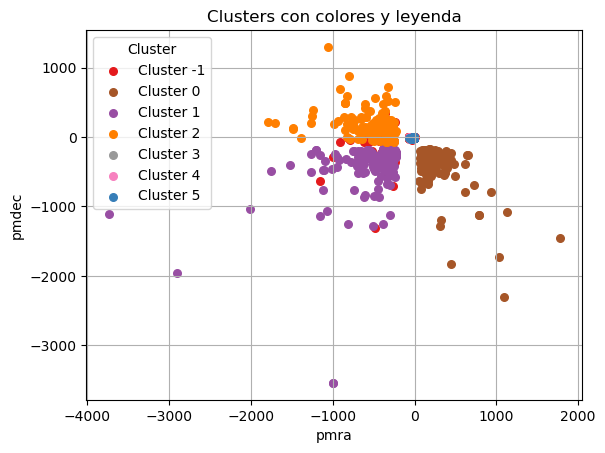

In [15]:
# Dibujar cada cluster por separado para asignar label
for cluster in clusters:
    subset = dff[dff['cluster'] == cluster]
    plt.scatter(subset['pmra'], subset['pmdec'],
                color=[color_dict[cluster]],
                label=f'Cluster {cluster}', s=30)

plt.xlabel('pmra')
plt.ylabel('pmdec')
plt.title('Clusters con colores y leyenda')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

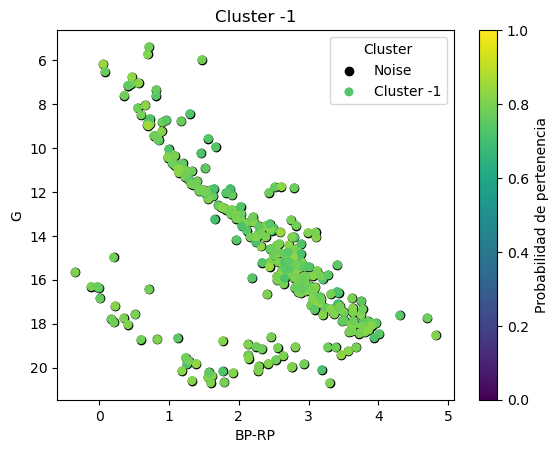

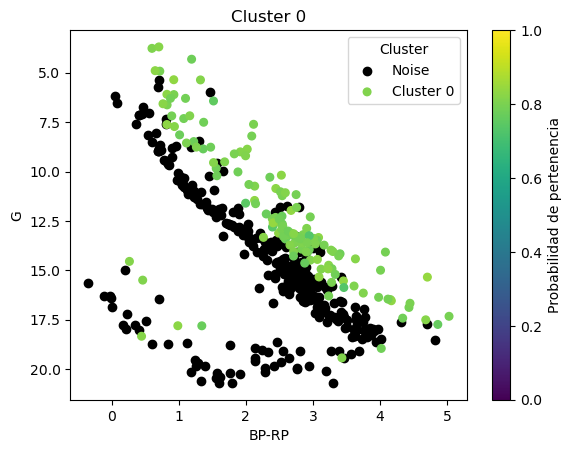

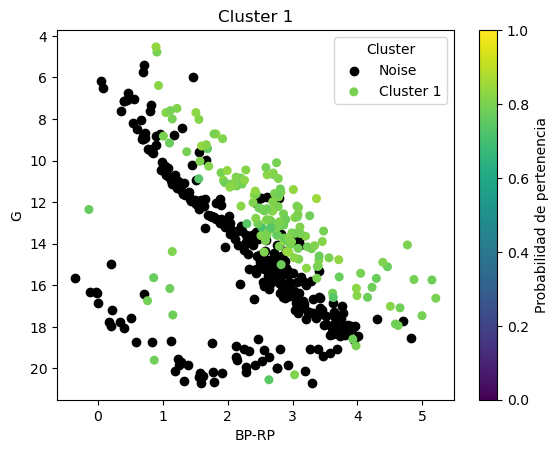

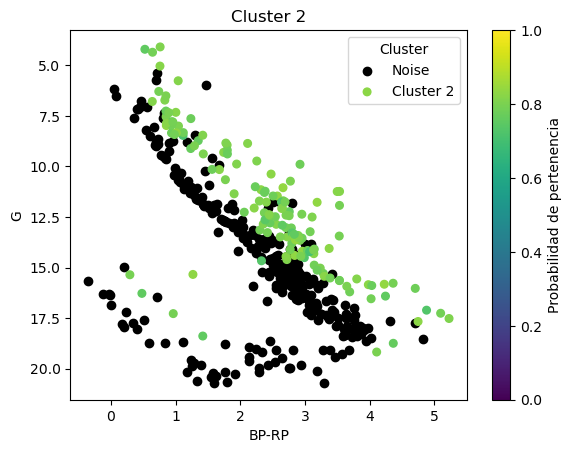

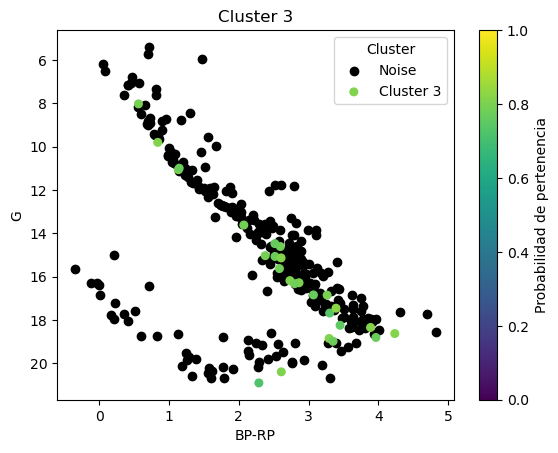

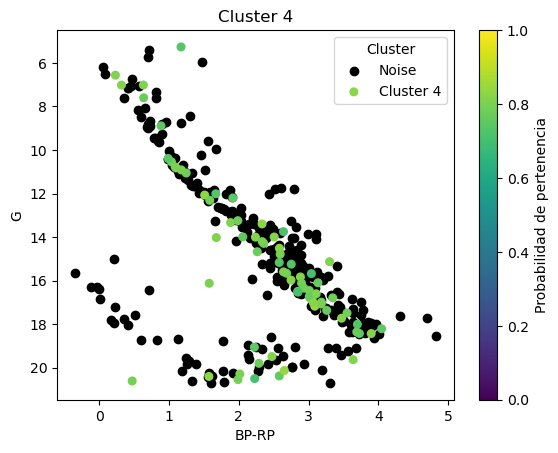

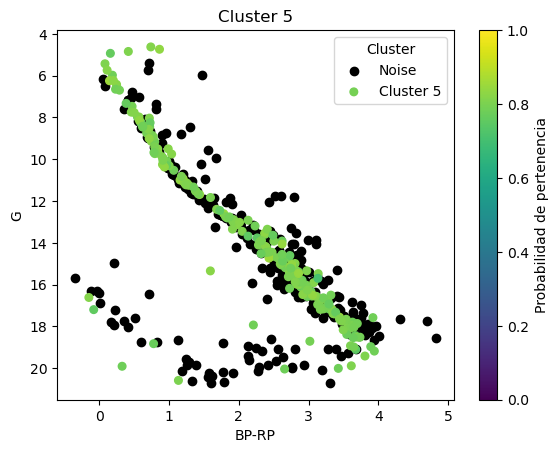

In [16]:
for cluster in clusters:
    subset = dff[dff['cluster'] == cluster]

    # Dibujar ruido en negro con alfa fijo
    noise = dff[dff['cluster'] == -1]
    plt.scatter(noise['bp_rp'], noise['phot_g_mean_mag'], color='k', label='Noise')

    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['probabilidad']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.viridis

    # Crear scatter plot con color en función de la probabilidad
    sc = plt.scatter(subset['bp_rp'], subset['phot_g_mean_mag'],
                     c=prob,
                     cmap=cmap,
                     norm=norm,
                     s=30,
                     label=f'Cluster {cluster}')

    plt.xlabel('BP-RP')
    plt.ylabel('G')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.gca().invert_yaxis()

    # Agregar barra de color
    cbar = plt.colorbar(sc)
    cbar.set_label('Probabilidad de pertenencia')

    plt.savefig(f"ruta_imagenes_evolucion/diagramas_cm/diagrama_cluster_coma_{cluster}.png")
    plt.show()

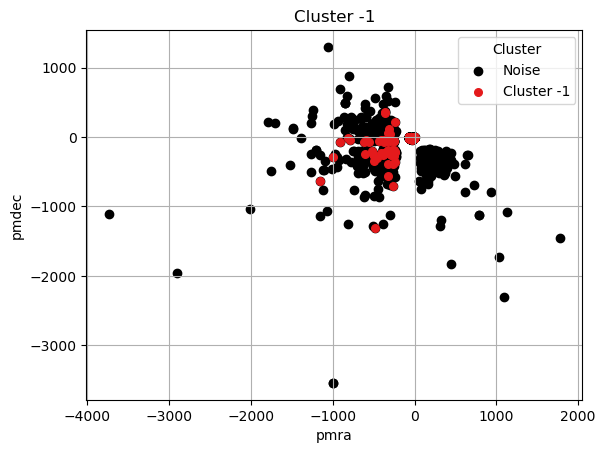

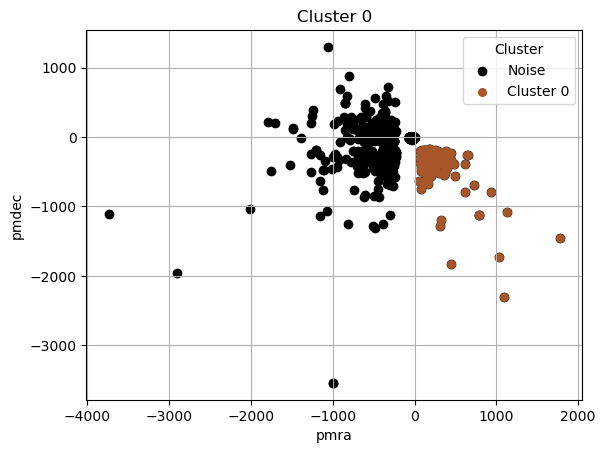

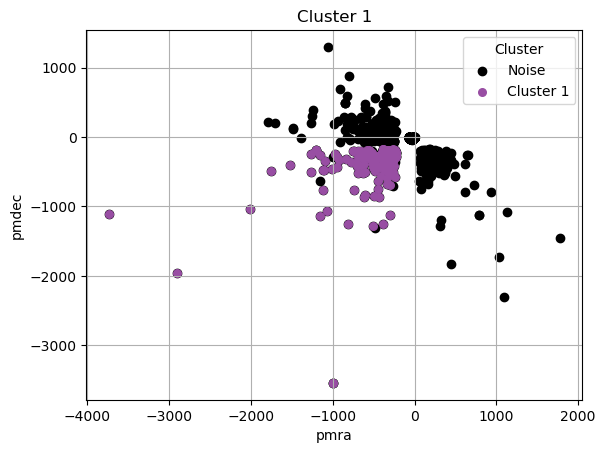

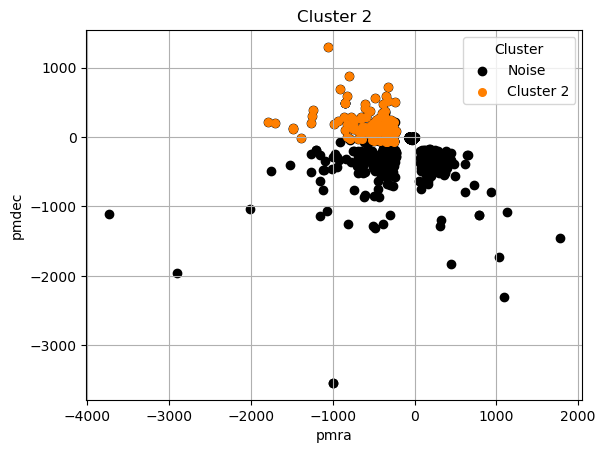

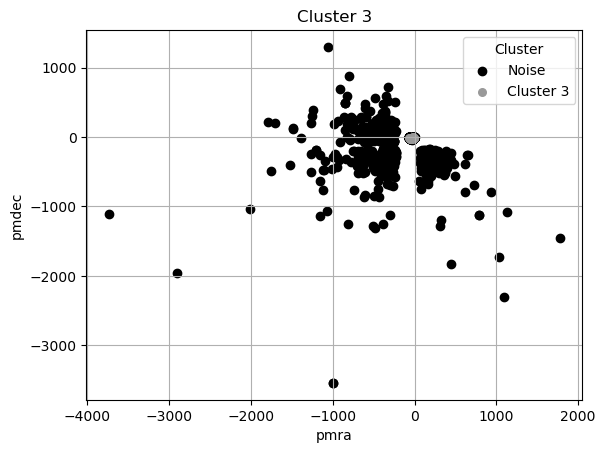

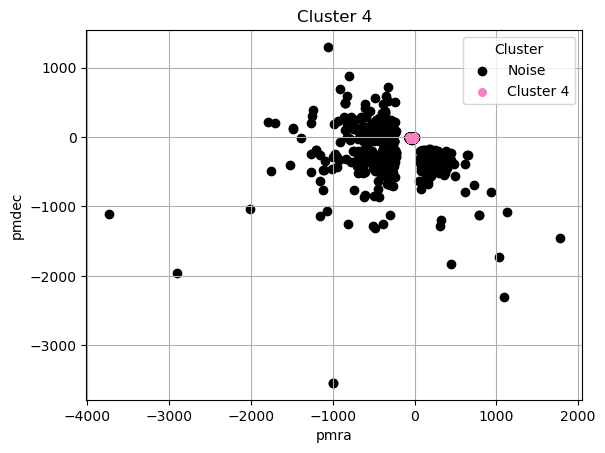

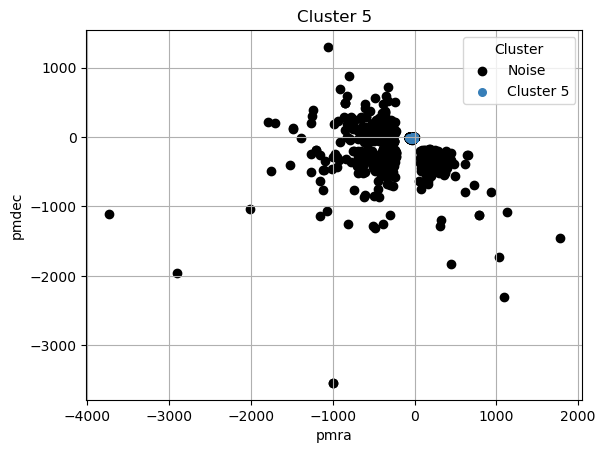

In [17]:
for cluster in clusters:
    subset = dff[dff['cluster'] == cluster]
    plt.scatter(df['pmra'],df['pmdec'], color='k', label='Noise')
    plt.scatter(subset['pmra'], subset['pmdec'],
                color=[color_dict[cluster]],
                label=f'Cluster {cluster}', s=30)

    plt.xlabel('pmra')
    plt.ylabel('pmdec')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.grid(True)
#     plt.savefig(f"ruta_imagenes_evolucion/diagramas_cm/diagrama_cluster_{cluster}.png")
    plt.show()

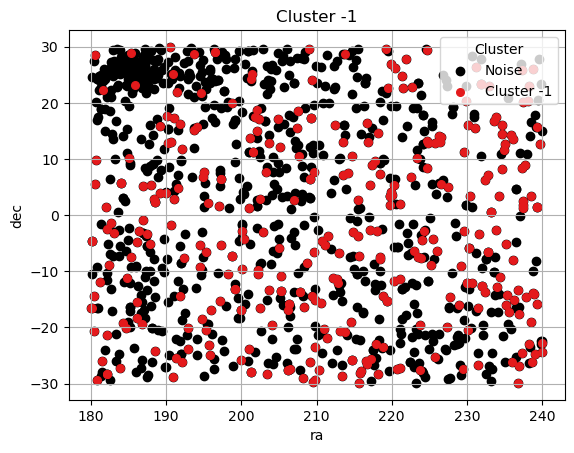

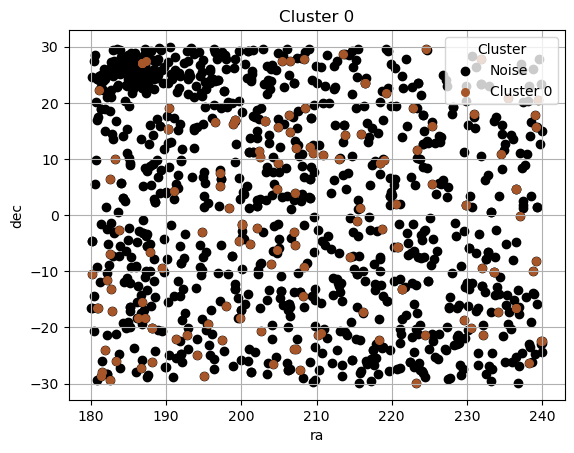

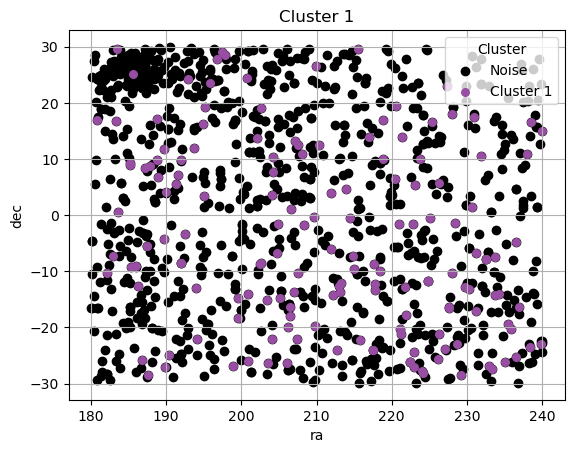

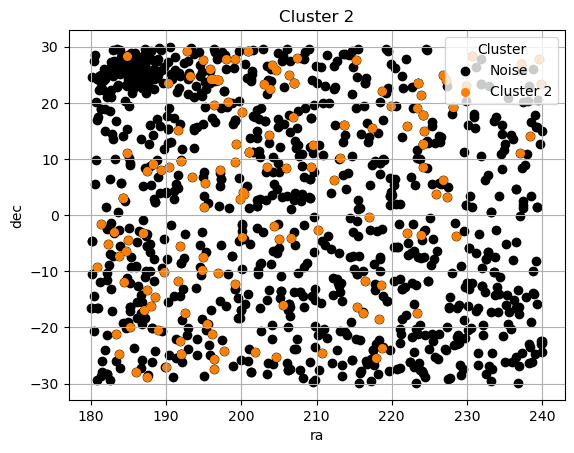

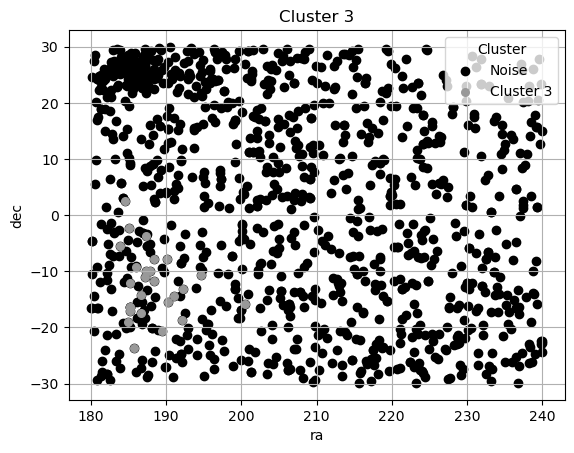

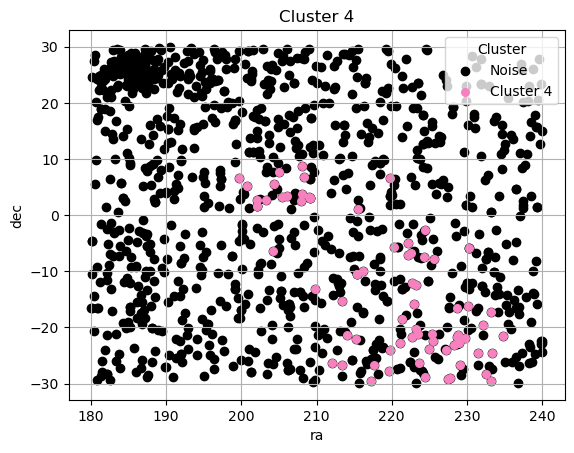

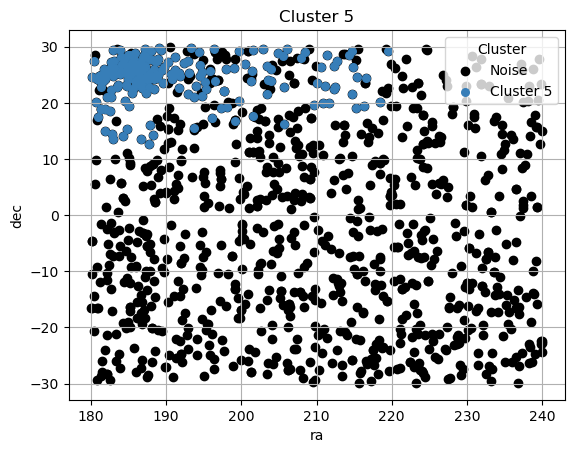

In [18]:
for cluster in clusters:
    subset = dff[dff['cluster'] == cluster]
    plt.scatter(df['ra'],df['dec'], color='k', label='Noise')
    plt.scatter(subset['ra'], subset['dec'],
                color=[color_dict[cluster]],
                label=f'Cluster {cluster}', s=30)

    plt.xlabel('ra')
    plt.ylabel('dec')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.grid(True)
#     plt.savefig(f"ruta_imagenes_evolucion/diagramas_cm/diagrama_cluster_{cluster}.png")
    plt.show()

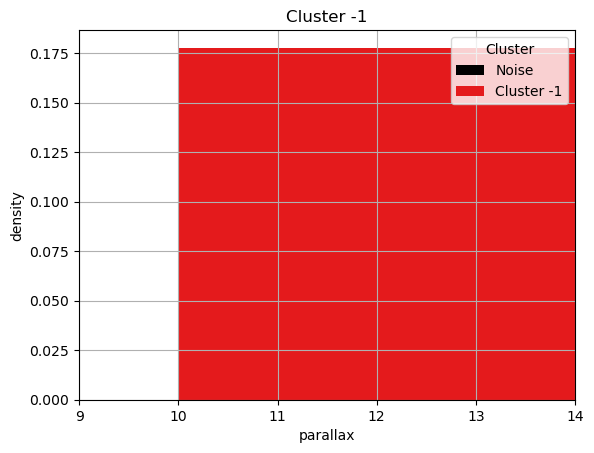

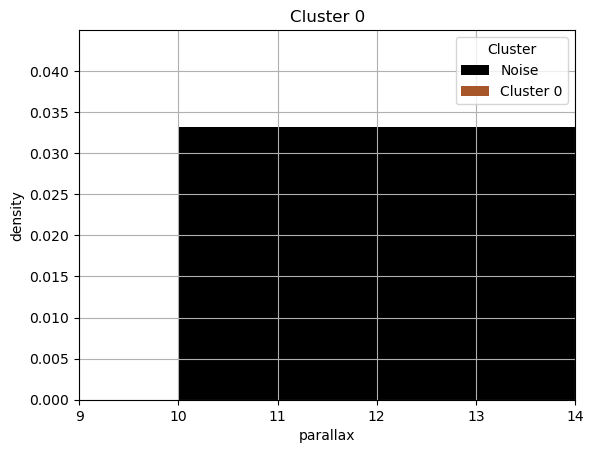

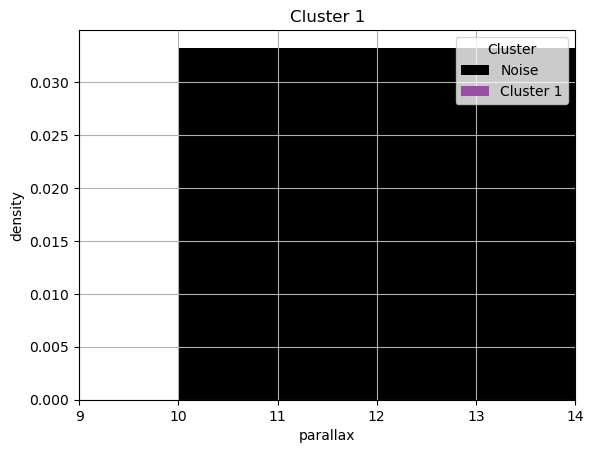

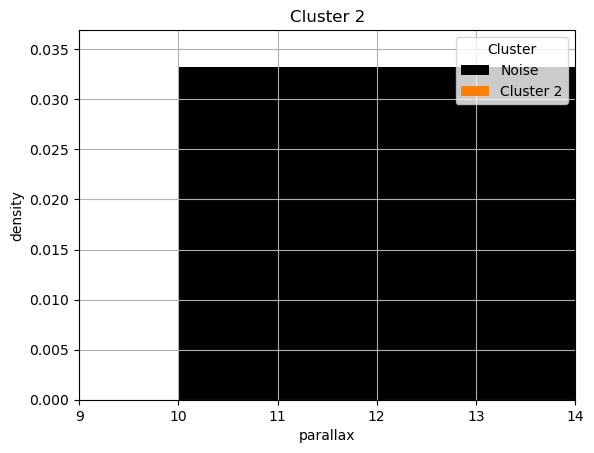

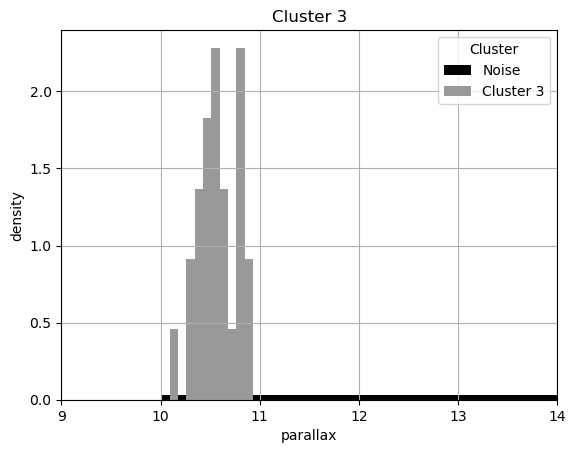

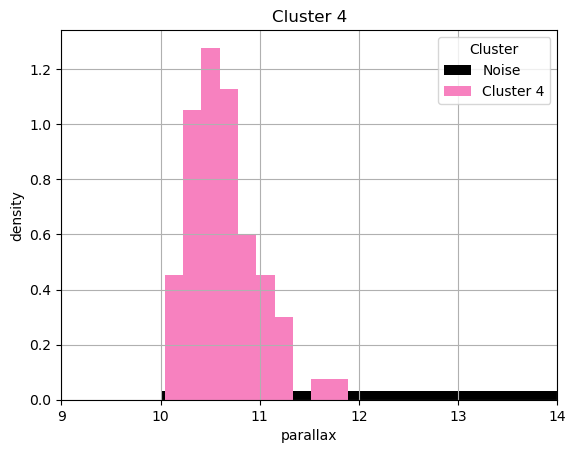

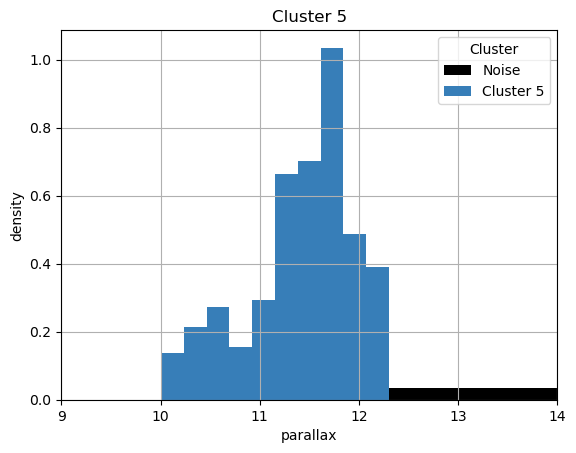

In [50]:
for cluster in clusters:
    subset = dff[dff['cluster'] == cluster]
    plt.hist(df['parallax'], color='k', label='Noise', density = True)
    plt.hist(subset['parallax'],color=[color_dict[cluster]],
                label=f'Cluster {cluster}', density=True)

    plt.xlabel('parallax')
    plt.ylabel('density')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.xlim(9,14)
    plt.grid(True)
#     plt.savefig(f"ruta_imagenes_evolucion/diagramas_cm/diagrama_cluster_{cluster}.png")
    plt.show()

(array([ 2.,  2.,  4.,  3.,  4.,  3.,  8.,  8.,  3., 11., 10.,  9.,  8.,
        13., 17., 14., 10., 15.,  9., 14., 14., 10., 11., 15., 16., 14.,
        23., 18., 21., 34., 25., 22., 10., 23., 25.,  8.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.,  0.,  1.,  7.,  2.,  4.,  1.,  3.,  5.,  3.,
         2.,  1.,  4.,  3.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  6., 17., 13., 30., 32., 40., 19., 22., 33., 16., 16.,
        18., 37., 36., 56., 54., 62., 27., 30., 36.]),
 array([ 4.32678479,  5.28346462,  6.24014446,  7.19682429,  8.15350413,
         9.11018396, 10.0668638 , 11.02354363, 11.98022347, 12.9369033 ,
        13.89358314, 14.85026297, 15.80694281, 16.76362264, 17.72030248,
        18.67698231, 19.63366215, 20.59034198, 21.54702182, 22.50370166,
        23.46038149, 24.41706133, 25.37374116, 26.330421  , 27.28710083,
        28.24378067, 29.2004605 , 30.15714034, 31.11382017, 32.070500

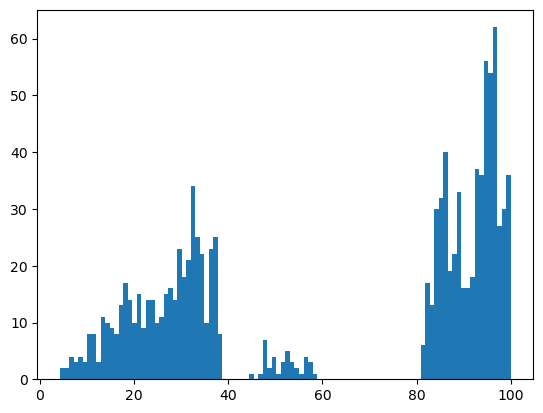

In [20]:
plt.hist(1000/df['parallax'], bins=100)

In [21]:
feature_cols = ['pmra_norm', 'pmdec_norm','parallax_norm']
silhouette_por_cluster = silhouette_por_cluster_dataframe(dff, cluster_col='cluster', feature_cols=feature_cols).reset_index()
silhouette_por_distancia = silhouette_por_cluster_dataframe(dff, cluster_col='cluster', feature_cols=['x_pc','y_pc','z_pc']).reset_index()
probabilidad_cluster = dff.groupby(['cluster']).agg({'probabilidad':'median','source_id':'count'}).reset_index()
silhouette_por_cluster = silhouette_por_cluster.merge(probabilidad_cluster, how='inner', on=['cluster']).merge(silhouette_por_distancia.rename(columns={'silhouette':'silhouette_distancia'}), how='inner', on=['cluster'])
silhouette_por_cluster.sort_values(by=['probabilidad','silhouette'], ascending=[False,False])

,cluster,silhouette,probabilidad,source_id,silhouette_distancia
0,0,0.973257,0.80000,139,-0.062113
5,5,0.523007,0.80000,223,0.701958
1,1,0.940576,0.79875,158,0.004861
2,2,0.793259,0.79500,143,0.018141
3,3,0.004205,0.78875,26,0.707681
4,4,-0.195409,0.78750,72,0.370111


In [22]:
df_temp = df.groupby(['cluster']).agg({'parallax':'mean','source_id':'count'}).reset_index()
df_temp['distancia'] = 1000/df['parallax']
df_temp[df_temp['distancia']<80]

,cluster,parallax,source_id,distancia


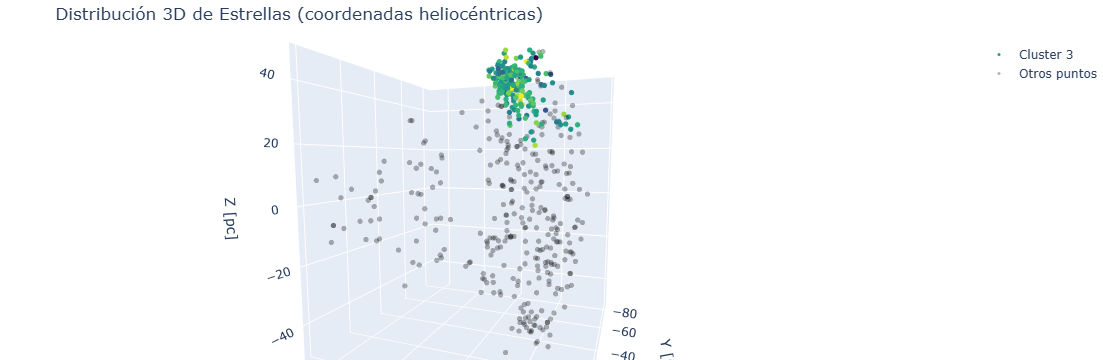

In [54]:
# Primer conjunto de puntos (cluster 3)
df_temp = df[df['cluster'] == 5]
df_otro = df[df['cluster'] == -1]
trace1 = go.Scatter3d(
    x=df_temp['x_pc'],
    y=df_temp['y_pc'],
    z=df_temp['z_pc'],
    mode='markers',
    marker=dict(
        size=3,
        color=df_temp['probabilidad'],
        colorscale='Viridis',
        opacity=1
    ),
    name='Cluster 3'
)

# Segundo conjunto de puntos (otros, en negro)
trace2 = go.Scatter3d(
    x=df_otro['x_pc'],
    y=df_otro['y_pc'],
    z=df_otro['z_pc'],
    mode='markers',
    marker=dict(
        size=3,
        color='black',  # color fijo en negro
        opacity=0.3
    ),
    name='Otros puntos'
)

# Crear la figura con ambas trazas
fig = go.Figure(data=[trace1, trace2])

fig.update_layout(
    scene=dict(
        xaxis_title='X [pc]',
        yaxis_title='Y [pc]',
        zaxis_title='Z [pc]'
    ),
    title='Distribución 3D de Estrellas (coordenadas heliocéntricas)',
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()


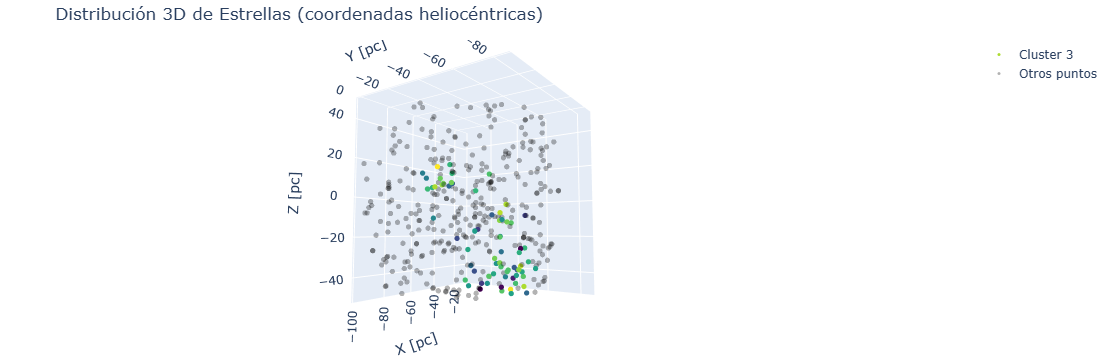

In [58]:
# Primer conjunto de puntos (cluster 3)
df_temp = df[df['cluster'] == ]
df_otro = df[df['cluster'] == -1]
trace1 = go.Scatter3d(
    x=df_temp['x_pc'],
    y=df_temp['y_pc'],
    z=df_temp['z_pc'],
    mode='markers',
    marker=dict(
        size=3,
        color=df_temp['probabilidad'],
        colorscale='Viridis',
        opacity=1
    ),
    name='Cluster 3'
)

# Segundo conjunto de puntos (otros, en negro)
trace2 = go.Scatter3d(
    x=df_otro['x_pc'],
    y=df_otro['y_pc'],
    z=df_otro['z_pc'],
    mode='markers',
    marker=dict(
        size=3,
        color='black',  # color fijo en negro
        opacity=0.3
    ),
    name='Otros puntos'
)

# Crear la figura con ambas trazas
fig = go.Figure(data=[trace1, trace2])

fig.update_layout(
    scene=dict(
        xaxis_title='X [pc]',
        yaxis_title='Y [pc]',
        zaxis_title='Z [pc]'
    ),
    title='Distribución 3D de Estrellas (coordenadas heliocéntricas)',
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

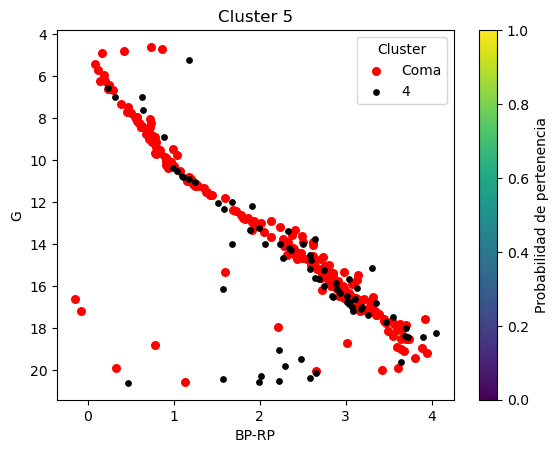

In [64]:
    subset = dff[dff['cluster'] == 5]

    # Dibujar ruido en negro con alfa fijo
    noise = dff[dff['cluster'] == 4]
    sc = plt.scatter(subset['bp_rp'], subset['phot_g_mean_mag'],
                     c='r',
                     s=30,
                     label=f'Coma')
    plt.scatter(noise['bp_rp'], noise['phot_g_mean_mag'], color='k', label='4', s=15)

    # Obtener la probabilidad y normalizarla si es necesario
    prob = subset['probabilidad']
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = cm.viridis

    # Crear scatter plot con color en función de la probabilidad

    plt.xlabel('BP-RP')
    plt.ylabel('G')
    plt.title(f'Cluster {cluster}')
    plt.legend(title='Cluster')
    plt.gca().invert_yaxis()

    # Agregar barra de color
    cbar = plt.colorbar(sc)
    cbar.set_label('Probabilidad de pertenencia')
    plt.show()